#### Общий когортный анализ покупателей с момента из первого заказа за 2017 год

C:\Users\Katem\AppData\Local\Temp\ipykernel_31980\2366959848.py:66: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,january,february,march,april,may,june,july,august,september,october,november,december
first_payment_month,,,,,,,,,,,,
January,765,3,2,1,3,1,4,1,1,0,3,1
February,0,1752,4,5,2,7,2,4,3,3,4,2
March,0,0,2636,13,10,10,9,4,4,8,9,2
April,0,0,0,2353,14,5,4,8,6,8,7,7
May,0,0,0,0,3596,18,18,14,11,12,15,6
June,0,0,0,0,0,3139,15,11,13,8,12,12
July,0,0,0,0,0,0,3895,20,14,10,11,8
August,0,0,0,0,0,0,0,4184,29,14,11,15
September,0,0,0,0,0,0,0,0,4131,28,22,12


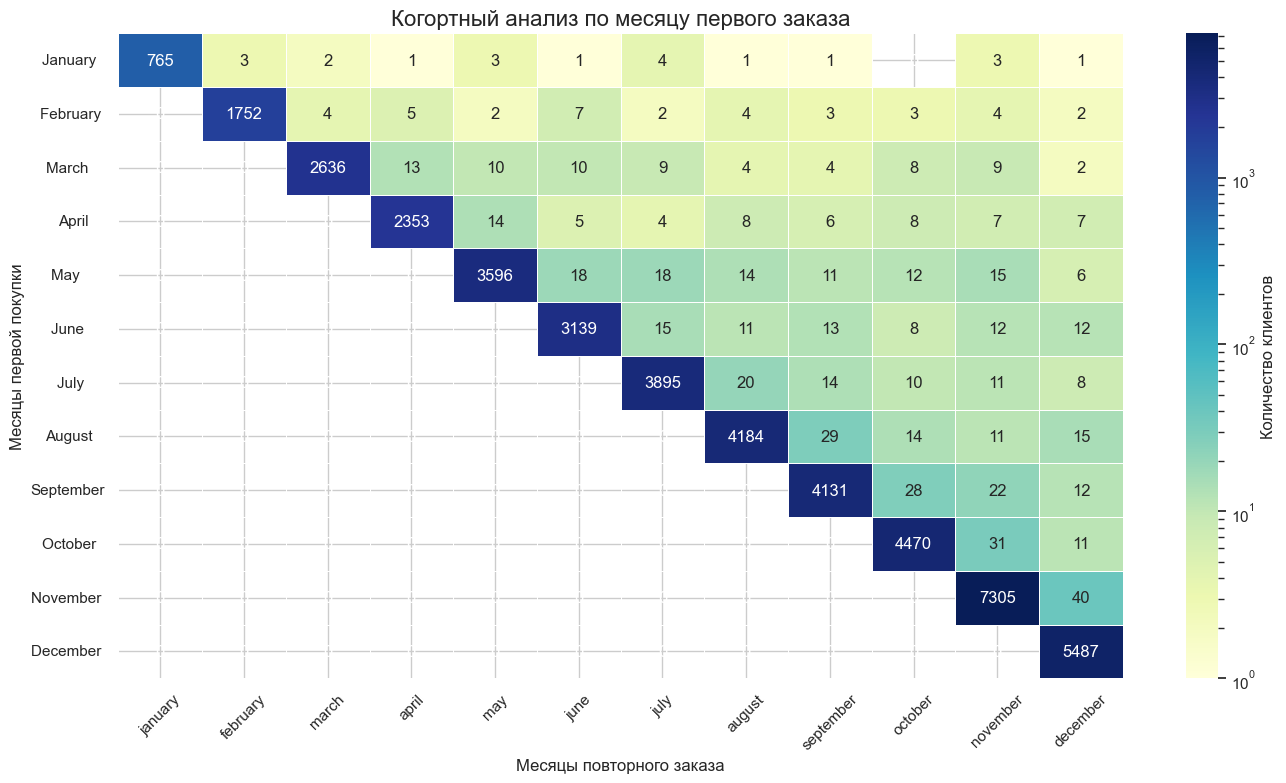

In [23]:
import pandas as pd
import psycopg2
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    MIN(DATE_TRUNC('month', o.order_purchase_timestamp)) AS first_cohort_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' 
    AND date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1
)

SELECT
  TO_CHAR(first_cohort_month, 'Month') AS first_payment_month,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'January' THEN fp.customer_unique_id END) AS January,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'February' THEN fp.customer_unique_id END) AS February,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'March' THEN fp.customer_unique_id END) AS March,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'April' THEN fp.customer_unique_id END) AS April,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November,
  COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'December' THEN fp.customer_unique_id END) AS December
FROM
  orders o
JOIN 
  order_payments op ON o.order_id = op.order_id
JOIN 
  customers c ON o.customer_id = c.customer_id
JOIN 
  first_payment fp ON c.customer_unique_id = fp.customer_unique_id
WHERE 
  date(o.order_purchase_timestamp) >= DATE '2017-01-01' 
  AND date(o.order_purchase_timestamp) < DATE '2018-01-01'
  AND DATE_TRUNC('month', o.order_purchase_timestamp) >= fp.first_cohort_month
GROUP BY 
  1, first_cohort_month
ORDER BY 
  first_cohort_month;
'''

df = pd.read_sql_query(query, conn)
conn.close()

df.set_index('first_payment_month', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

df.columns = [col.lower() for col in df.columns]

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

month_order = ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']
df = df[month_order]

from matplotlib.colors import LogNorm

plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

ax = sns.heatmap(
    df,
    annot=True,
    fmt='d',
    cmap="YlGnBu",
    linewidths=.5,
    norm=LogNorm(vmin=max(1, df[df > 0].min().min()), vmax=df.max().max()),
    cbar_kws={'label': 'Количество клиентов'}
)

plt.title("Когортный анализ по месяцу первого заказа", fontsize=16)
plt.xlabel("Месяцы повторного заказа")
plt.ylabel("Месяцы первой покупки")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Когорты по штатам (%). Первая покупка - Июнь

C:\Users\Katem\AppData\Local\Temp\ipykernel_29572\3451459901.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,july_percent,august_percent,september_percent,october_percent,november_percent,december_percent,returnability_stability,rating
customer_state,,,,,,,,,
SP,1283,0.31,0.23,0.39,0.16,0.31,0.39,6,A
RS,215,0.47,0.93,0.93,0.47,0.00,0.47,5,A
MG,351,0.28,0.00,0.28,0.28,0.28,0.28,5,A
RJ,401,1.00,0.00,0.25,0.00,0.75,0.25,4,A
ES,79,0.00,1.27,1.27,1.27,0.00,1.27,4,A
PR,166,0.60,0.60,1.20,0.60,0.00,0.00,4,A
PE,44,0.00,4.55,0.00,2.27,0.00,0.00,2,B
SC,112,0.00,0.00,0.89,0.00,0.00,0.89,2,B
MT,24,8.33,0.00,0.00,0.00,0.00,4.17,2,B


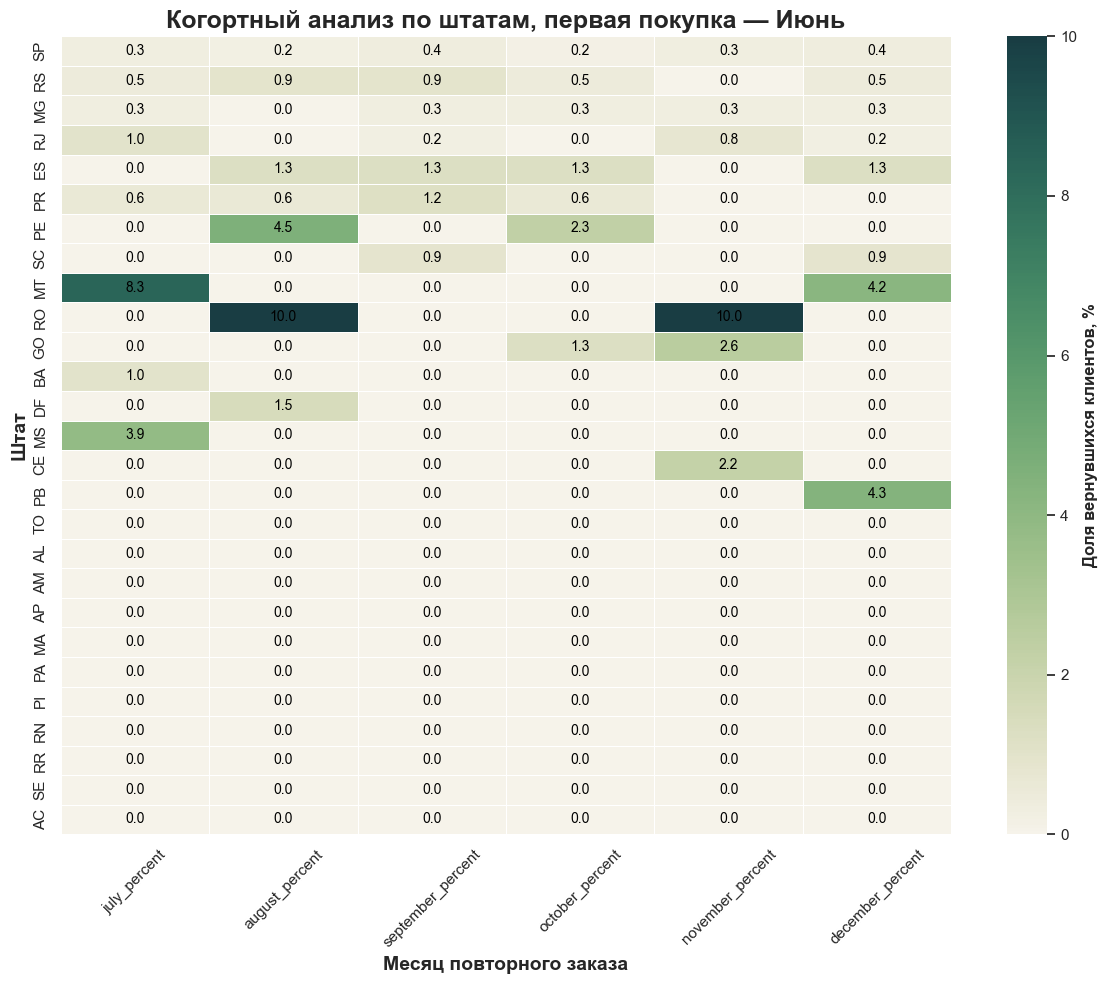

In [18]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS(
    SELECT
      c.customer_unique_id,
      c.customer_state,
      TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
    FROM 
      orders o 
    JOIN 
      order_payments op ON o.order_id = op.order_id
    JOIN 
      customers c ON o.customer_id = c.customer_id
    WHERE 
      date(o.order_purchase_timestamp) >= '2017-01-01' AND 
      date(o.order_purchase_timestamp) < '2018-01-01'
    GROUP BY
      1, 2
  ), cohort_state_customers AS(
    SELECT
      fp.customer_state,
      fp.first_payment_month,
      COUNT(DISTINCT CASE WHEN first_payment_month = 'June' THEN fp.customer_unique_id END) AS total_customers,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November,
      COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'December' THEN fp.customer_unique_id END) AS December
    FROM
      orders o
    JOIN 
      order_payments op ON o.order_id = op.order_id
    JOIN 
      customers c ON o.customer_id = c.customer_id
    JOIN 
      first_payment fp ON c.customer_unique_id = fp.customer_unique_id
    WHERE 
      date(o.order_purchase_timestamp) >= '2017-01-01' AND 
      date(o.order_purchase_timestamp) < '2018-01-01' AND
      fp.first_payment_month = 'June'
    GROUP BY 
      1, 2
  ), cohort_with_returnability_stability AS(
  SELECT 
    customer_state, 
    total_customers,
    ROUND(July * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS July_percent, 
    ROUND(August * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS August_percent, 
    ROUND(September * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS September_percent,
    ROUND(October * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS October_percent, 
    ROUND(November * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS November_percent,
    ROUND(December * 1.0 / NULLIF(total_customers, 0) * 100, 2) AS December_percent,
    (CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END +
     CASE WHEN December > 0 THEN 1 ELSE 0 END) AS returnability_stability
  FROM
    cohort_state_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('customer_state', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent', 'december_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

green_palette = sns.cubehelix_palette(start=2.8, rot=-0.5, light=0.95, dark=0.2, as_cmap=True)

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=green_palette, 
    linewidths=0.5,
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "medium", "color": "black"}
)

plt.title("Когортный анализ по штатам, первая покупка — Июнь", fontsize=18, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=14, fontweight='bold')
plt.ylabel("Штат", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

#### Когорты по штатам (%). Первая покупка - Май

C:\Users\Katem\AppData\Local\Temp\ipykernel_29572\636950416.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,june_percent,july_percent,august_percent,september_percent,october_percent,november_percent,returnability_stability,rating
customer_state,,,,,,,,,
SP,1387,0.58,0.58,0.22,0.58,0.29,0.22,6,A
RJ,475,0.42,0.63,0.42,0.00,0.42,0.63,5,A
ES,90,1.11,2.22,3.33,1.11,1.11,0.00,5,A
RS,202,0.00,0.99,0.99,0.00,0.50,0.50,4,A
MG,415,0.24,0.24,0.00,0.00,0.24,0.72,4,A
PR,206,0.00,0.49,0.00,0.49,0.00,0.49,3,B
BA,123,0.81,0.00,0.81,0.00,0.00,1.63,3,B
SC,151,0.66,0.00,0.00,0.00,0.00,1.32,2,B
PI,25,0.00,0.00,0.00,4.00,4.00,0.00,2,B


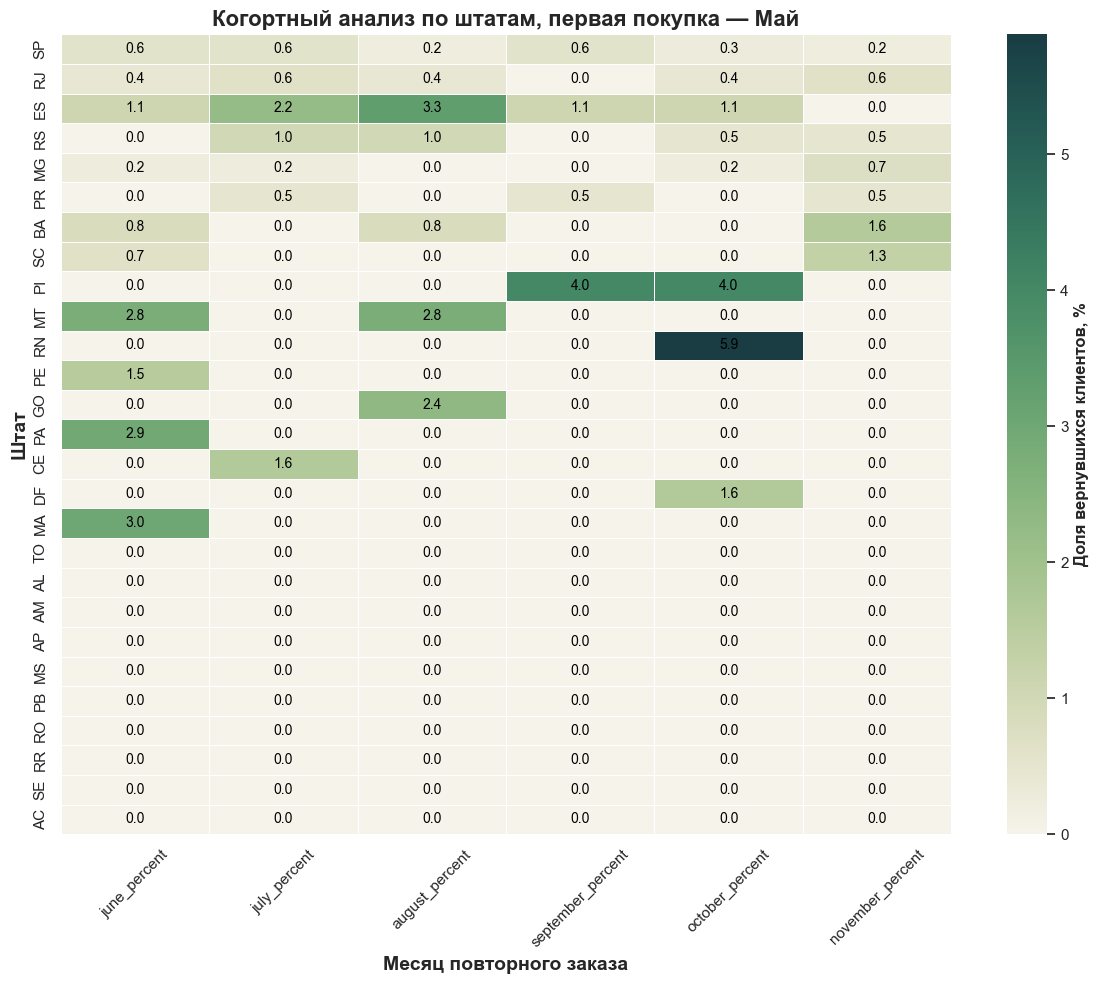

In [20]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  customer_state, 
  total_customers,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('customer_state', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

green_palette = sns.cubehelix_palette(start=2.8, rot=-0.5, light=0.95, dark=0.2, as_cmap=True)

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=green_palette, 
    linewidths=0.5,
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "medium", "color": "black"}
)

plt.title("Когортный анализ по штатам, первая покупка — Май", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=14, fontweight='bold')
plt.ylabel("Штат", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

#### Когорты по штатам (%). Первая покупка - Апрель

C:\Users\Katem\AppData\Local\Temp\ipykernel_29572\2121628085.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,may_percent,june_percent,july_percent,august_percent,september_percent,october_percent,returnability_stability,rating
customer_state,,,,,,,,,
MG,270,1.48,0.37,0.00,0.37,0.37,0.74,5,A
SP,884,0.45,0.23,0.00,0.57,0.11,0.45,5,A
RJ,327,0.61,0.00,0.31,0.00,0.61,0.31,4,A
SC,105,0.00,0.00,0.00,0.95,0.95,0.95,3,B
BA,93,1.08,1.08,0.00,1.08,0.00,0.00,3,B
PR,113,1.77,0.00,0.88,0.00,0.00,0.00,2,B
AC,5,0.00,20.00,0.00,0.00,0.00,0.00,1,B
AL,22,0.00,0.00,0.00,0.00,4.55,0.00,1,B
RS,135,0.00,0.00,1.48,0.00,0.00,0.00,1,B


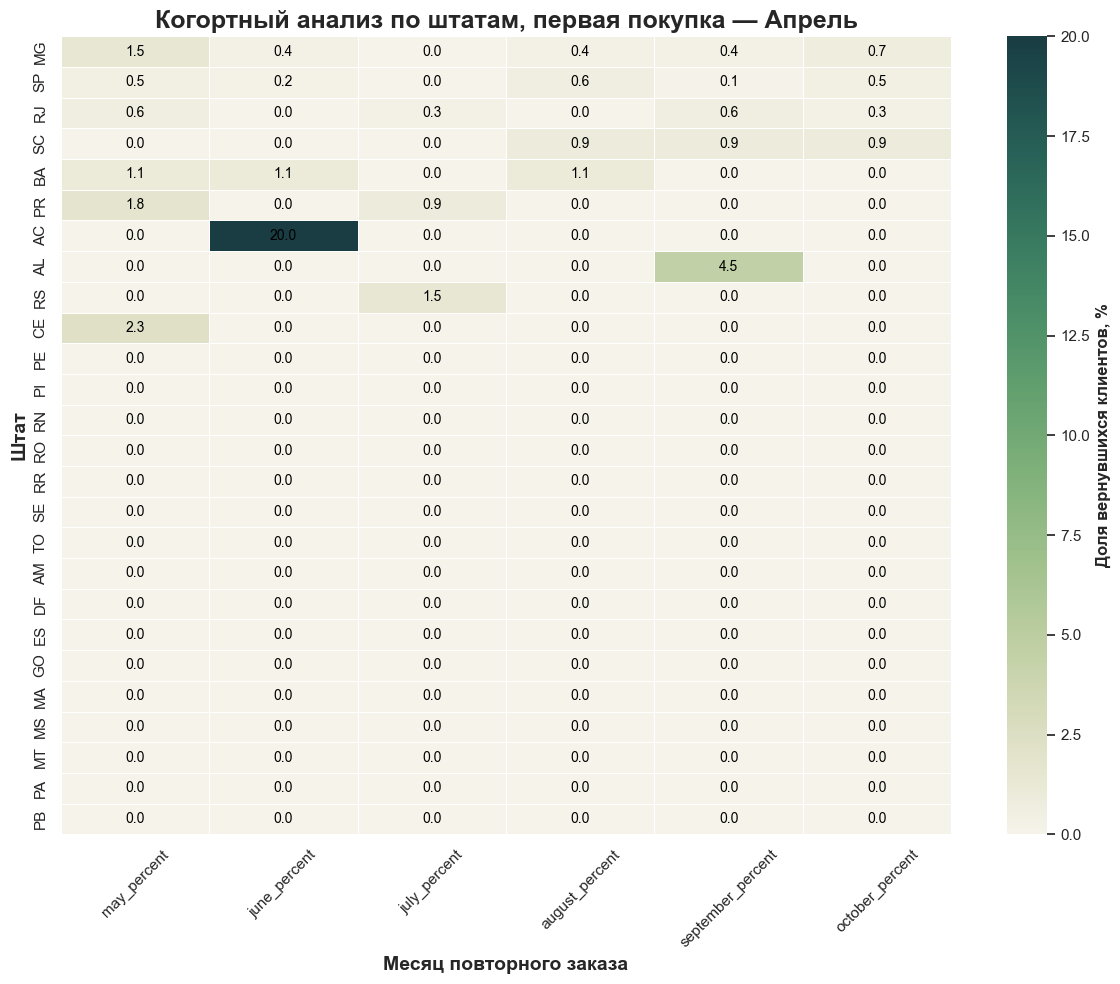

In [19]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'April' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'April'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  customer_state, 
  total_customers,
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent,
  (CASE WHEN May > 0 THEN 1 ELSE 0 END + 
     CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('customer_state', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['may_percent', 'june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

green_palette = sns.cubehelix_palette(start=2.8, rot=-0.5, light=0.95, dark=0.2, as_cmap=True)

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=green_palette, 
    linewidths=0.5,
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "medium", "color": "black"}
)

plt.title("Когортный анализ по штатам, первая покупка — Апрель", fontsize=18, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=14, fontweight='bold')
plt.ylabel("Штат", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Вывод: На основе когортного анализа пользователей по штатам, где первый заказ клиентов был совершен в Июне, Мае и Апреле соответственно, наблюдается устойчивая динамика возврата клиентов. Наиболее высокие показатели стабильности удержания демонстрируют практически одни и те же штаты, в их числе - крупнейшие и густонаселенные регионы. Средний уровень возвращаемости характерен для части центральных и южных регионов, в то время как минимальные или нулевые значения возвратов в основном наблюдаются в отдалённых или малонаселённых штатах. Таким образом, одной из гипотез относительно возвращаемости клиентов в штатах может являться средняя стоимость доставки, которая, в свою очередь, обусловлена удаленностью от логистических пунктов с товарами. Следовательно, чтобы повысить уровень удержания покупателей, рекомендуется расширить логистическую инфраструктуру, в том числе количество складов и пунктов выдачи товаров, ближе к отдаленным регионам.

#### Подтверждение гипотезы

C:\Users\Katem\AppData\Local\Temp\ipykernel_18388\2160921414.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  price_df = pd.read_sql_query(price_query, conn)
C:\Users\Katem\AppData\Local\Temp\ipykernel_18388\2160921414.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  returnability_stability_df = pd.read_sql_query(returnability_stability_query, conn)


,avg_freight_price
customer_state,
SP,15.02
MG,19.50
PR,19.52
SC,19.65
DF,20.02
RJ,20.05
RS,20.57
ES,20.92
MS,21.61


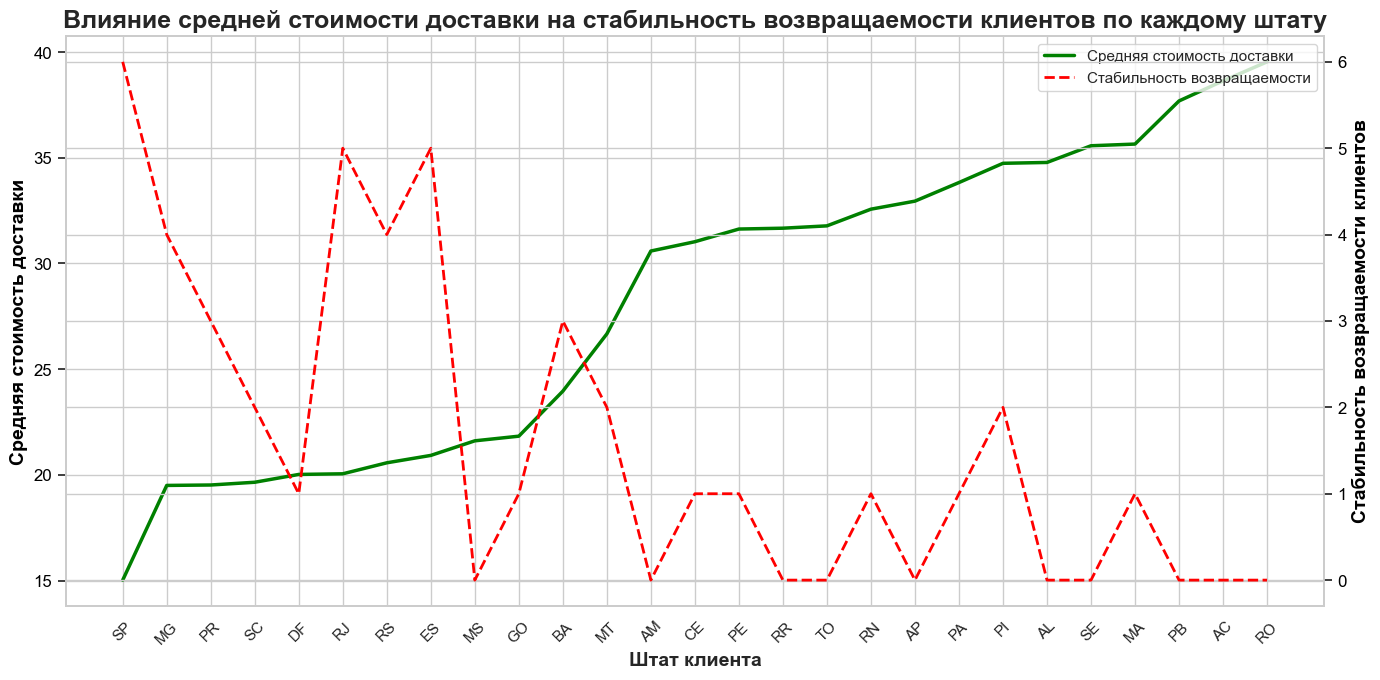

In [7]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

price_query = '''
  select
	customer_state,
	ROUND(avg(freight_value)::numeric, 2) AS avg_freight_price
from 
	orders_items oi 
	join orders o on oi.order_id = o.order_id
	join customers c on o.customer_id = c.customer_id
where 
	date(order_purchase_timestamp) >= '2017-01-01' and date(order_purchase_timestamp) < '2018-01-01'
group by
	1
order by
	2;
'''

returnability_stability_query = '''
WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
)
SELECT 
  customer_state, 
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers
ORDER BY returnability_stability DESC;
'''

price_df = pd.read_sql_query(price_query, conn)
returnability_stability_df = pd.read_sql_query(returnability_stability_query, conn)

conn.close()

price_df.set_index('customer_state', inplace=True)
returnability_stability_df.set_index('customer_state', inplace=True)

if price_df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(price_df)

# ВИЗУАЛИЗАЦИЯ
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1, rc={"axes.labelweight": "bold", "font.weight": "medium"})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Первая ось — средняя стоимость доставки
sns.lineplot(
    ax=ax1,
    x=price_df.index,
    y=price_df['avg_freight_price'],
    color='green',
    linewidth=2.5,
    label='Средняя стоимость доставки'
)
ax1.set_xlabel('Штат клиента', fontsize=14, fontweight='bold')
ax1.set_ylabel('Средняя стоимость доставки', fontsize=14, fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.set_title('Влияние средней стоимости доставки на стабильность возвращаемости клиентов по каждому штату',
              fontsize=18, fontweight='bold')

# Вторая ось — стабильность возвращаемости
ax2 = ax1.twinx()
sns.lineplot(
    ax=ax2,
    x=returnability_stability_df.index,
    y=returnability_stability_df['returnability_stability'],
    color='red',
    linewidth=2,
    linestyle='--',
    label='Стабильность возвращаемости'
)
ax2.set_ylabel('Стабильность возвращаемости клиентов', fontsize=14, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.get_legend().remove()
ax2.get_legend().remove()

custom_lines = [
    plt.Line2D([0], [0], color='green', lw=2.5, label='Средняя стоимость доставки'),
    plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Стабильность возвращаемости')
]

ax1.legend(handles=custom_lines, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

#### Когорты по способу оплаты (%). Первая покупка - Июнь

C:\Users\Katem\AppData\Local\Temp\ipykernel_26716\3278845377.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,july_percent,august_percent,september_percent,october_percent,november_percent,december_percent,returnability_stability,rating
payment_type,,,,,,,,,
boleto,686,0.58,0.44,0.29,0.15,0.15,0.58,6,A
credit_card,2377,0.46,0.34,0.46,0.29,0.46,0.34,6,A
voucher,136,0.00,0.00,0.00,0.00,1.47,0.00,1,B
debit_card,26,0.00,0.00,0.00,0.00,0.00,0.00,0,C


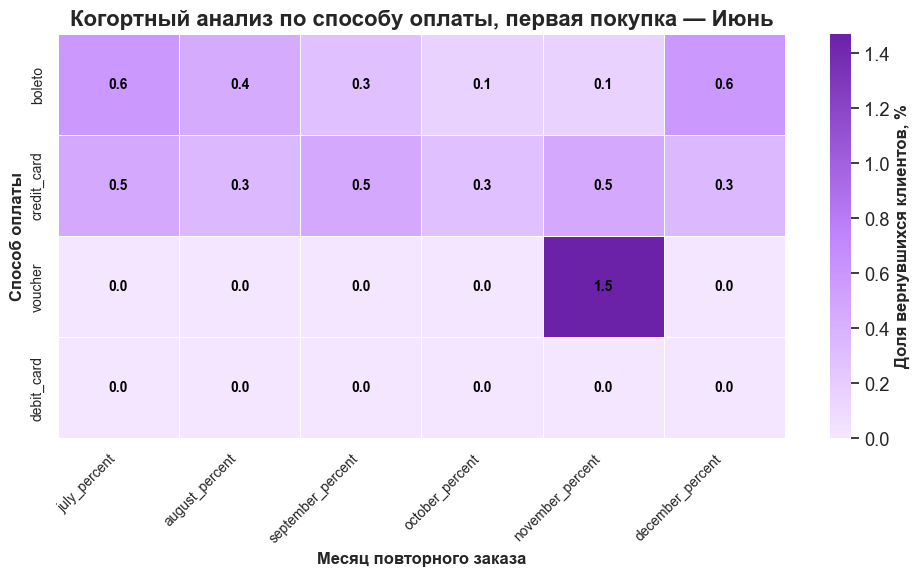

In [3]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    payment_type,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_payment_type_customers AS (
  SELECT
    fp.payment_type,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'June' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'December' THEN fp.customer_unique_id END) AS December
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'June'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  payment_type, 
  total_customers,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  ROUND(December * 1.0 / total_customers * 100, 2) AS December_percent,
  (CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END +
     CASE WHEN December > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_payment_type_customers)
  
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('payment_type', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent', 'december_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

purple_palette = LinearSegmentedColormap.from_list("pretty_purple", ["#f5e6ff", "#c084fc", "#6b21a8"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=purple_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по способу оплаты, первая покупка — Июнь", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Способ оплаты", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по способу оплаты (%). Первая покупка - Май

C:\Users\Katem\AppData\Local\Temp\ipykernel_26716\3955537298.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,june_percent,july_percent,august_percent,september_percent,october_percent,november_percent,returnability_stability,rating
payment_type,,,,,,,,,
boleto,756,0.13,0.53,0.40,0.53,0.13,0.13,6,A
credit_card,2755,0.62,0.51,0.36,0.25,0.36,0.47,6,A
voucher,166,0.60,0.60,1.20,0.60,0.60,2.41,6,A
debit_card,29,0.00,0.00,0.00,0.00,0.00,0.00,0,C


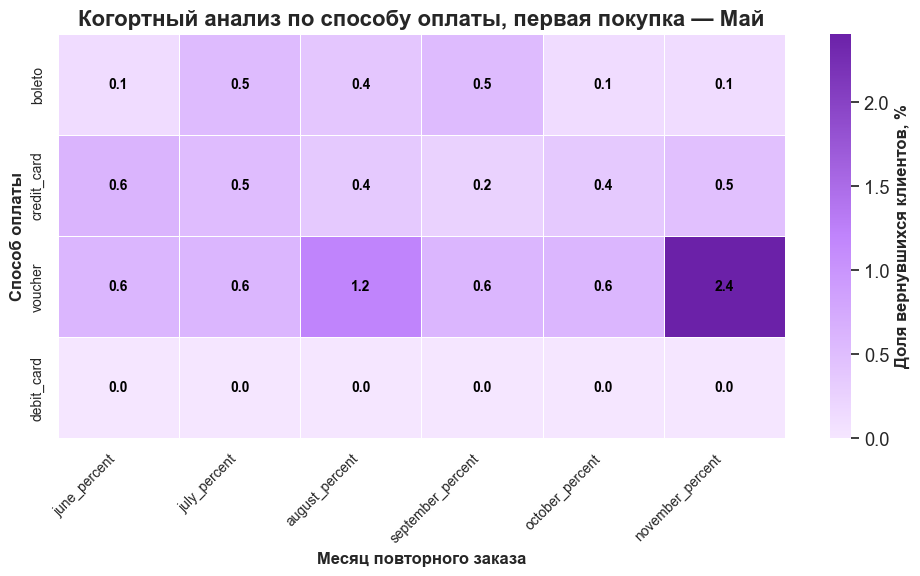

In [4]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    payment_type,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_payment_type_customers AS (
  SELECT
    fp.payment_type,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  payment_type, 
  total_customers,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_payment_type_customers)
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('payment_type', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

purple_palette = LinearSegmentedColormap.from_list("pretty_purple", ["#f5e6ff", "#c084fc", "#6b21a8"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=purple_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по способу оплаты, первая покупка — Май", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Способ оплаты", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по способу оплаты (%). Первая покупка - Апрель

C:\Users\Katem\AppData\Local\Temp\ipykernel_26716\700345966.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,may_percent,june_percent,july_percent,august_percent,september_percent,october_percent,returnability_stability,rating
payment_type,,,,,,,,,
credit_card,1799,0.61,0.17,0.22,0.39,0.33,0.39,6,A
boleto,489,0.61,0.20,0.00,0.20,0.00,0.20,4,A
debit_card,26,0.00,3.85,0.00,0.00,0.00,0.00,1,B
voucher,113,0.00,0.00,0.00,0.00,0.00,0.88,1,B


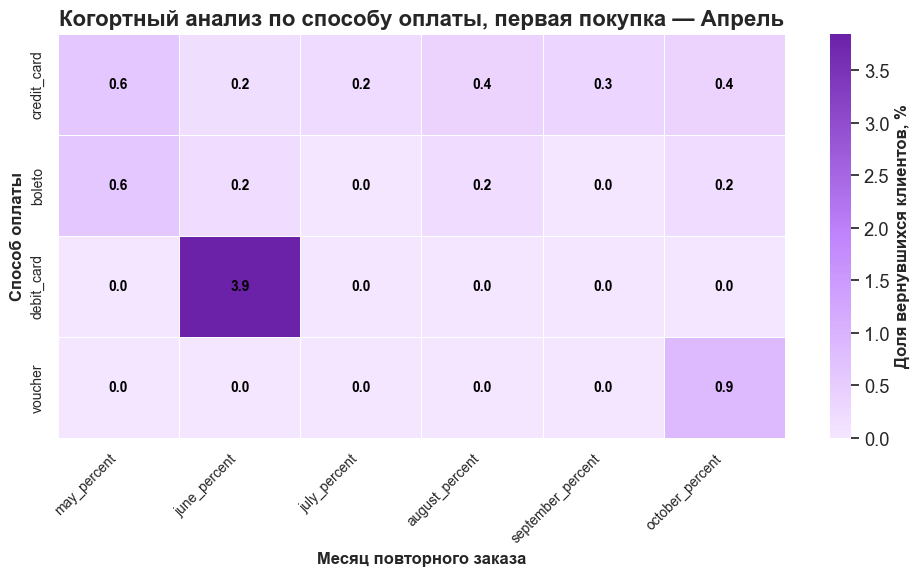

In [5]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    payment_type,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_payment_type_customers AS (
  SELECT
    fp.payment_type,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'April' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October
  FROM
  orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'April'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  payment_type,
  total_customers, 
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  (CASE WHEN May > 0 THEN 1 ELSE 0 END +
     CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_payment_type_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('payment_type', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['may_percent', 'june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

purple_palette = LinearSegmentedColormap.from_list("pretty_purple", ["#f5e6ff", "#c084fc", "#6b21a8"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=purple_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по способу оплаты, первая покупка — Апрель", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Способ оплаты", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Когорты по способу оплаты (%). Первая покупка - Март

C:\Users\Katem\AppData\Local\Temp\ipykernel_26716\4167588026.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,april_percent,may_percent,june_percent,july_percent,august_percent,september_percent,returnability_stability,rating
payment_type,,,,,,,,,
credit_card,1979,0.51,0.25,0.35,0.35,0.2,0.15,6,A
boleto,579,0.52,0.86,0.17,0.17,0.0,0.17,5,A
debit_card,31,0.00,0.00,3.23,3.23,0.0,0.00,2,B
voucher,119,0.00,0.84,0.84,0.00,0.0,0.00,2,B


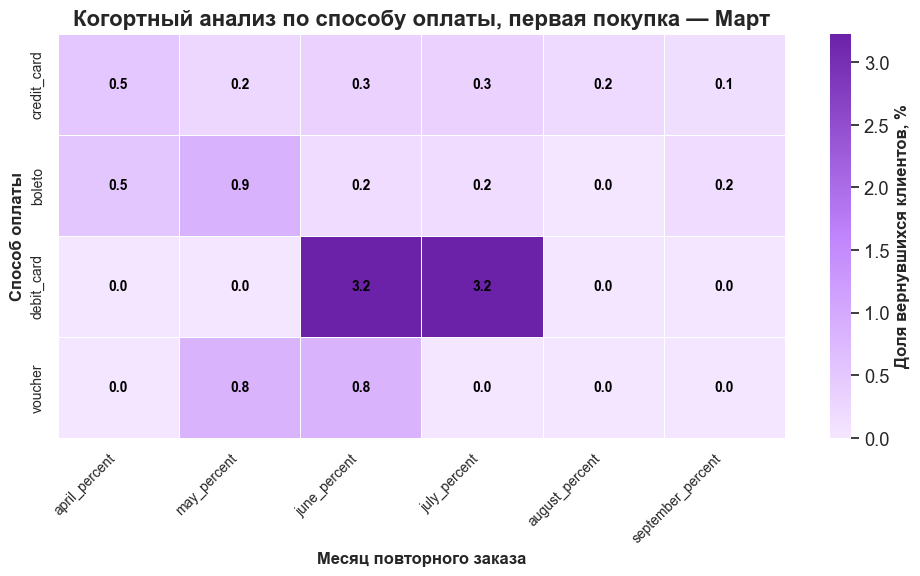

In [6]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    payment_type,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_payment_type_customers AS (
  SELECT
    fp.payment_type,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'March' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'April' THEN fp.customer_unique_id END) AS April,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September
  FROM
  orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'March'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  payment_type,
  total_customers, 
  ROUND(April * 1.0 / total_customers * 100, 2) AS April_percent, 
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  (CASE WHEN April > 0 THEN 1 ELSE 0 END +
     CASE WHEN May > 0 THEN 1 ELSE 0 END +
     CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_payment_type_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('payment_type', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['april_percent', 'may_percent', 'june_percent', 'july_percent', 'august_percent', 'september_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

purple_palette = LinearSegmentedColormap.from_list("pretty_purple", ["#f5e6ff", "#c084fc", "#6b21a8"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=purple_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по способу оплаты, первая покупка — Март", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Способ оплаты", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Когорты по способу оплаты (%). Первая покупка - Февраль

C:\Users\Katem\AppData\Local\Temp\ipykernel_26716\2155283038.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,march_percent,april_percent,may_percent,june_percent,july_percent,august_percent,returnability_stability,rating
payment_type,,,,,,,,,
credit_card,1323,0.23,0.30,0.15,0.30,0.08,0.23,6,A
boleto,395,0.25,0.25,0.00,0.76,0.25,0.25,5,A
voucher,68,1.47,0.00,0.00,0.00,0.00,0.00,1,B
debit_card,13,0.00,0.00,0.00,0.00,0.00,0.00,0,C


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'credit_card'),
  Text(0, 1.5, 'boleto'),
  Text(0, 2.5, 'voucher'),
  Text(0, 3.5, 'debit_card')])

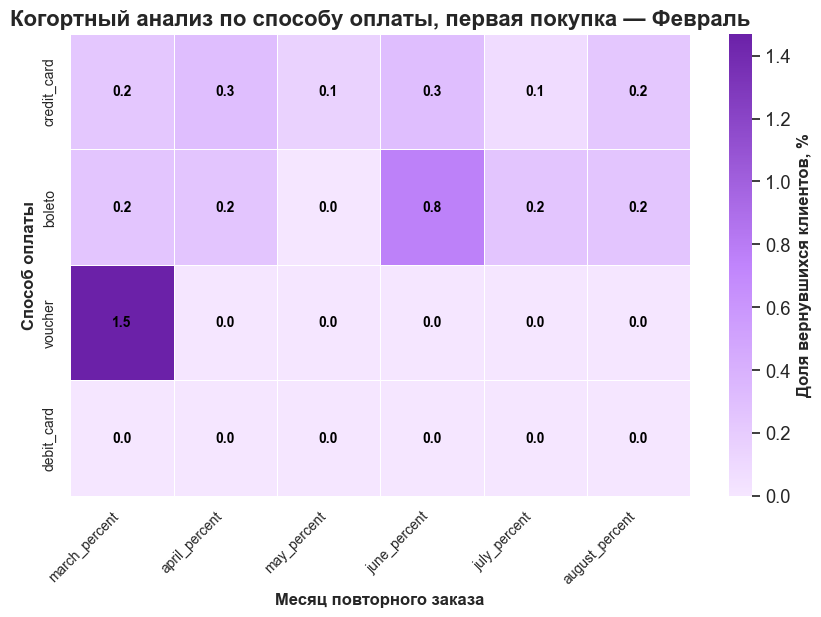

In [14]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    payment_type,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_payment_type_customers AS (
  SELECT
    fp.payment_type,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'February' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'March' THEN fp.customer_unique_id END) AS March,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'April' THEN fp.customer_unique_id END) AS April,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August
  FROM
  orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'February'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  payment_type,
  total_customers, 
  ROUND(March * 1.0 / total_customers * 100, 2) AS March_percent,
  ROUND(April * 1.0 / total_customers * 100, 2) AS April_percent, 
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent,
  (CASE WHEN March > 0 THEN 1 ELSE 0 END +
     CASE WHEN April > 0 THEN 1 ELSE 0 END +
     CASE WHEN May > 0 THEN 1 ELSE 0 END +
     CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_payment_type_customers)
  SELECT 
    *,
    (CASE 
        WHEN returnability_stability > 3 THEN 'A'
        WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
        WHEN returnability_stability = 0 THEN 'C'
     END) AS rating
  FROM 
    cohort_with_returnability_stability
  ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('payment_type', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['march_percent', 'april_percent', 'may_percent', 'june_percent', 'july_percent', 'august_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

purple_palette = LinearSegmentedColormap.from_list("pretty_purple", ["#f5e6ff", "#c084fc", "#6b21a8"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=purple_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по способу оплаты, первая покупка — Февраль", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Способ оплаты", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

Вывод: Когортный анализ пользователей по способу оплаты в большинстве случаев показывает устойчивое поведение в возврате клиентов. Высокой стабильностью удержания обладают люди, которые совершают оплаты кредитными картами или через платежную систему "болето". 
Кредитная карта - канал с наибольшим количеством клиентов. Можно предположить, что данный способ оплаты, а также оплата через болето, являются популярными среди штатов, которые обладают высокой стабильностью возвращаемости клиентов. 

Клиенты, которые оплачивали дебетовыми картами или ваучерами, возвращаются значительно реже. Вероятно, пользуясь ваучером, клиент просто решил воспользоваться одноразовой покупкой из-за более выгодной цены. В случае с дебетовыми картами, такое поведение клиентов может быть связано с их повышенной осознанностью трат и ограниченным бюджетом. 

Но при этом, для первой покупки, сделанной в Мае с применением ваучера, можно заметить возвращаемость клиентов каждый месяц на протяжении полугода. Это является отличительной особенностью по сравнению с другими когортами первых покупок. Возможно, такая ситуация также связана с тем, что заказы могли быть выполнены из штатов с высокой стабильностью возвращаемости покупателей.

#### Подтверждение гипотез относительно способов оплаты "credit_card" и "boleto"

C:\Users\Katem\AppData\Local\Temp\ipykernel_18388\1059308655.py:89: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_payments = pd.read_sql_query(query, conn)
C:\Users\Katem\AppData\Local\Temp\ipykernel_18388\1059308655.py:90: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_return = pd.read_sql_query(returnability_stability_query, conn)


,count_credit_card,count_boleto
customer_state,,
SP,15281,4224
RJ,5589,1273
MG,4724,1313
RS,2152,808
PR,1892,608
BA,1420,358
SC,1390,515
DF,827,212
GO,823,270


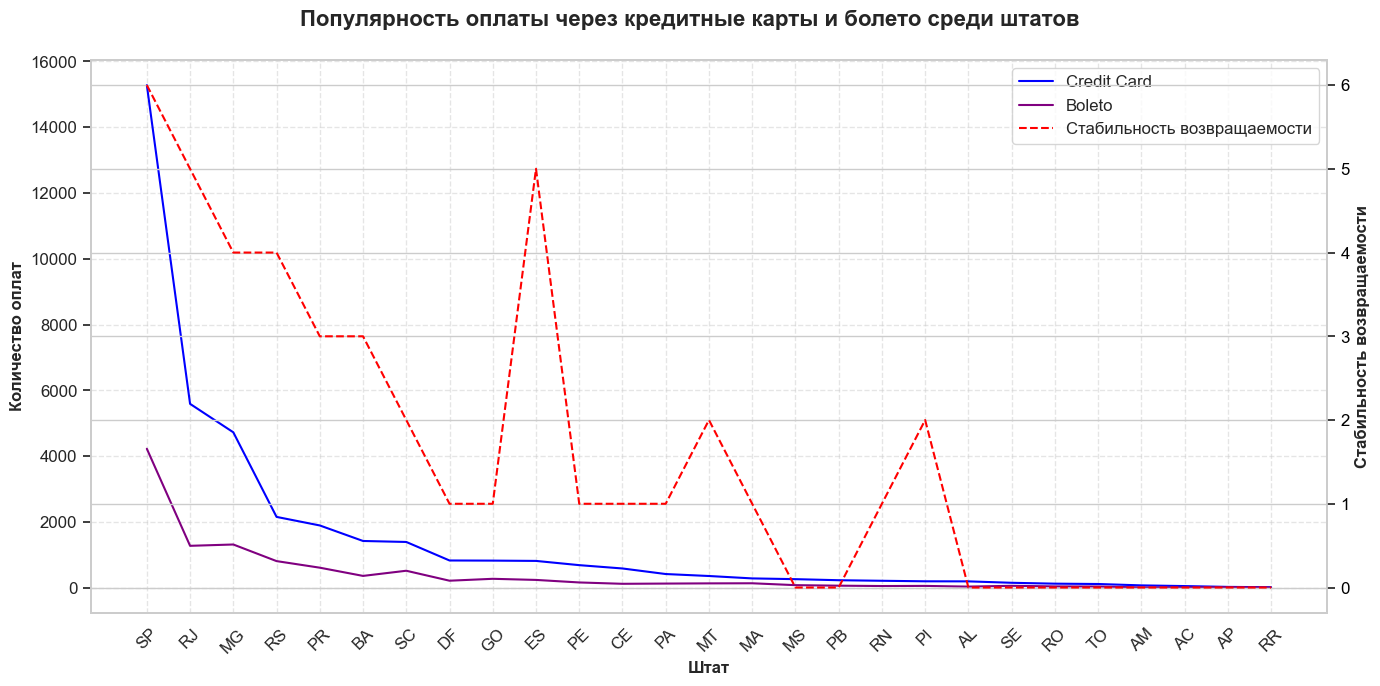

In [ ]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

#Данные затроились, для запроса на основной сервер убрать деление
query = '''
  select
	customer_state,
	COUNT(CASE WHEN payment_type = 'credit_card' THEN payment_type END) / 3 AS count_credit_card,
	COUNT(CASE WHEN payment_type = 'boleto' THEN payment_type END) / 3 AS count_boleto
from
    orders_items oi 
    join orders o on oi.order_id = o.order_id
    join order_payments op on o.order_id = op.order_id
    join customers c on o.customer_id = c.customer_id
where 
    date(order_purchase_timestamp) >= '2017-01-01' 
    AND date(order_purchase_timestamp) < '2018-01-01'
group by
    1
order by
    2 DESC, 3 DESC;
'''

returnability_stability_query = '''
WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
)
SELECT 
  customer_state, 
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers
ORDER BY returnability_stability DESC;
'''

df_payments = pd.read_sql_query(query, conn)
df_return = pd.read_sql_query(returnability_stability_query, conn)

conn.close()

df_payments.set_index('customer_state', inplace=True)
df_return.set_index('customer_state', inplace=True)

if df_payments.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df_payments)

# Убедимся, что индекс совпадает с df_payments
returnability_line = df_payments.index.map(df_return['returnability_stability'])

# ВИЗУАЛИЗАЦИЯ
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 7))

# Основные линии
ax1.plot(df_payments.index, df_payments['count_credit_card'], label='Credit Card', color='blue')
ax1.plot(df_payments.index, df_payments['count_boleto'], label='Boleto', color='purple')

# Первая ось — количество оплат
ax1.set_xlabel('Штат', fontsize=12)
ax1.set_ylabel('Количество оплат', fontsize=12)
ax1.tick_params(axis='y')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True, linestyle='--', alpha=0.5)

# Вторая ось — стабильность возвращаемости
ax2 = ax1.twinx()
ax2.plot(df_payments.index, returnability_line, color='red', linestyle='--', label='Стабильность возвращаемости')
ax2.set_ylabel('Стабильность возвращаемости', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

fig.suptitle('Популярность оплаты через кредитные карты и болето среди штатов', fontsize=16, weight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### Подтверждение гипотезы относительно резко отличающейся возвращаемости клиентов, совершивших первый заказ в Мае с применением ваучера

C:\Users\Katem\AppData\Local\Temp\ipykernel_2028\752980892.py:100: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
C:\Users\Katem\AppData\Local\Temp\ipykernel_2028\752980892.py:101: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_return = pd.read_sql_query(returnability_stability_query, conn)


,count_voucher_june,count_voucher_may,count_voucher_april
customer_state,,,
SP,58,76,45
RJ,18,17,16
MG,11,15,11
PR,5,13,6
SC,5,8,3
RS,8,5,5
ES,3,5,3
BA,9,4,5
GO,4,4,0


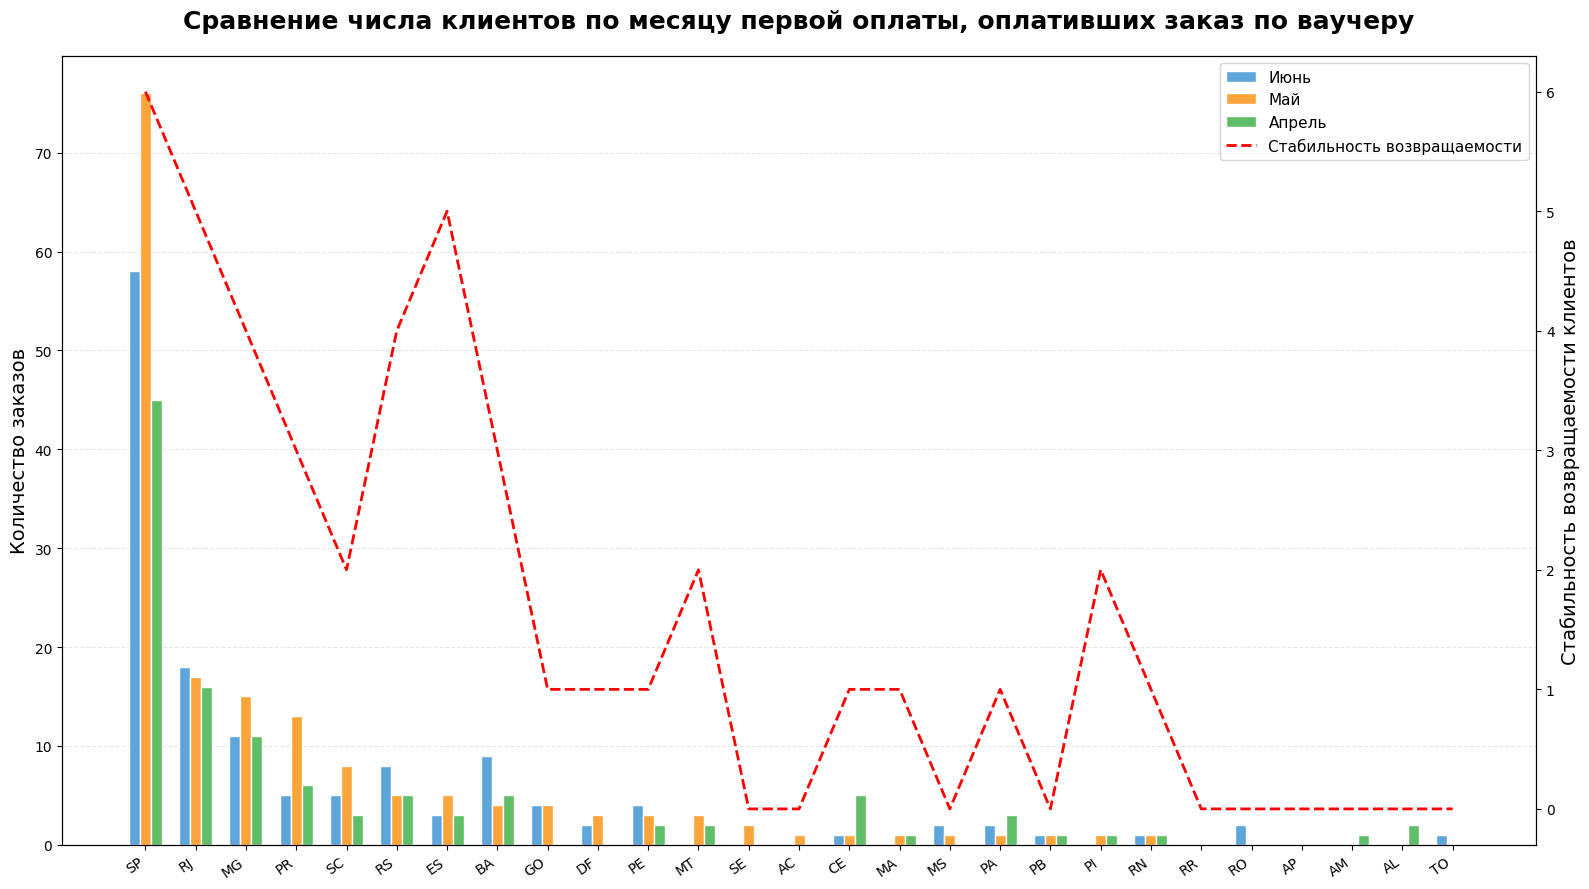

In [ ]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    op.payment_type,
    o.order_status,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN order_payments op ON o.order_id = op.order_id
  JOIN customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2, 3, 4
)
SELECT
  customer_state,
  COUNT(CASE WHEN payment_type = 'voucher' AND first_payment_month = 'June' THEN payment_type END) AS count_voucher_june,
  COUNT(CASE WHEN payment_type = 'voucher' AND first_payment_month = 'May' THEN payment_type END) AS count_voucher_may,
  COUNT(CASE WHEN payment_type = 'voucher' AND first_payment_month = 'April' THEN payment_type END) AS count_voucher_april
FROM 
  first_payment
GROUP BY
  1
ORDER BY
  count_voucher_may DESC;
'''

returnability_stability_query = '''
WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
)
SELECT 
  customer_state, 
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)
df_return = pd.read_sql_query(returnability_stability_query, conn)

conn.close()

df.set_index('customer_state', inplace=True)
df_return.set_index('customer_state', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import matplotlib.pyplot as plt
import numpy as np

colors = ['#5DA5DA', '#FAA43A', '#60BD68']

# Порядок штатов — как в df
states_order = df.sort_values(by='count_voucher_may', ascending=False).index.tolist()
df_return = df_return.reindex(states_order)

colors = ['#5DA5DA', '#FAA43A', '#60BD68']
df_plot = df.loc[states_order]

x = np.arange(len(states_order)) * 1.6
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 9))

ax1.bar(x - bar_width, df_plot['count_voucher_june'], width=bar_width, color=colors[0], label='Июнь', edgecolor='white')
ax1.bar(x, df_plot['count_voucher_may'], width=bar_width, color=colors[1], label='Май', edgecolor='white')
ax1.bar(x + bar_width, df_plot['count_voucher_april'], width=bar_width, color=colors[2], label='Апрель', edgecolor='white')

# Вторая ось и линия стабильности
ax2 = ax1.twinx()
ax2.plot(x, df_return['returnability_stability'], color='red', linestyle='--', linewidth=2, label='Стабильность возвращаемости')
ax2.set_ylabel('Стабильность возвращаемости клиентов', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_xticks(x)
ax1.set_xticklabels(states_order, fontsize=10, rotation=35, ha='right')
ax1.set_ylabel('Количество заказов', fontsize=14)
ax1.set_title('Сравнение числа клиентов по месяцу первой оплаты, оплативших заказ по ваучеру', fontsize=18, fontweight='bold', pad=20)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()


#### Когорты по статусу заказа (%). Первая покупка - Июнь

C:\Users\Katem\AppData\Local\Temp\ipykernel_9340\4046709249.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,july_percent,august_percent,september_percent,october_percent,november_percent,december_percent,returnability_stability,rating
order_status,,,,,,,,,
delivered,3037,0.49,0.4,0.46,0.3,0.43,0.36,6,A
canceled,16,6.25,0.0,0.00,0.0,0.00,6.25,2,B
invoiced,11,0.00,0.0,0.00,0.0,0.00,0.00,0,C
processing,12,0.00,0.0,0.00,0.0,0.00,0.00,0,C
shipped,47,0.00,0.0,0.00,0.0,0.00,0.00,0,C
unavailable,24,0.00,0.0,0.00,0.0,0.00,0.00,0,C


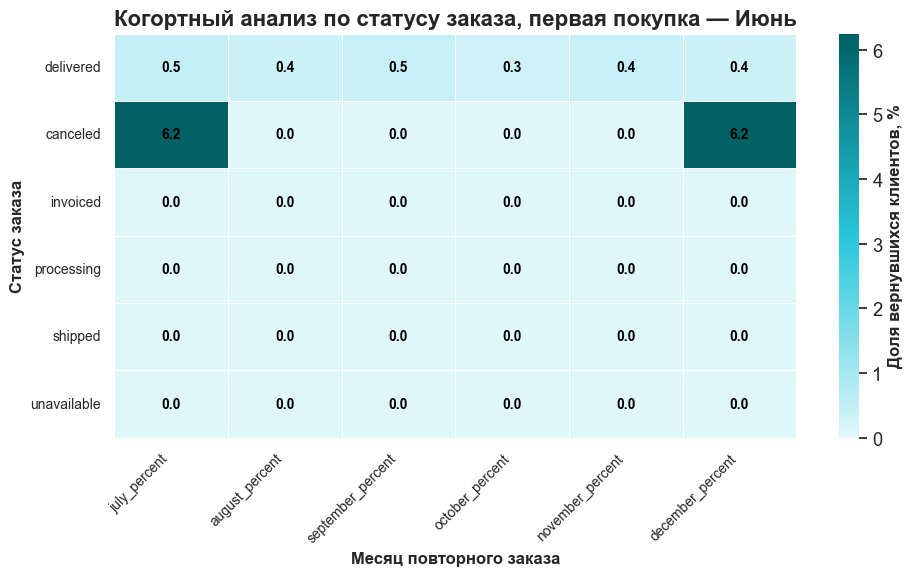

In [ ]:
import pandas as pd
import psycopg2
from IPython.display import display
\
conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    order_status,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_order_status_customers AS (
  SELECT
    fp.order_status,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'June' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'December' THEN fp.customer_unique_id END) AS December
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'June'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  order_status, 
  total_customers,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  ROUND(December * 1.0 / total_customers * 100, 2) AS December_percent,
  (CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END +
     CASE WHEN December > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_order_status_customers)
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('order_status', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent', 'december_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

blue_palette = LinearSegmentedColormap.from_list("pretty_turquoise", ["#e0f7fa", "#26c6da", "#006064"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=blue_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по статусу заказа, первая покупка — Июнь", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Статус заказа", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по статусу заказа (%). Первая покупка - Май

C:\Users\Katem\AppData\Local\Temp\ipykernel_9340\3682718305.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,june_percent,july_percent,august_percent,september_percent,october_percent,november_percent,returnability_stability,rating
order_status,,,,,,,,,
delivered,3451,0.46,0.46,0.32,0.29,0.32,0.41,6,A
shipped,55,3.64,1.82,3.64,1.82,1.82,1.82,6,A
canceled,29,3.45,3.45,0.00,0.00,0.00,0.00,2,B
processing,23,0.00,0.00,4.35,0.00,0.00,0.00,1,B
unavailable,31,0.00,3.23,0.00,0.00,0.00,0.00,1,B
invoiced,16,0.00,0.00,0.00,0.00,0.00,0.00,0,C


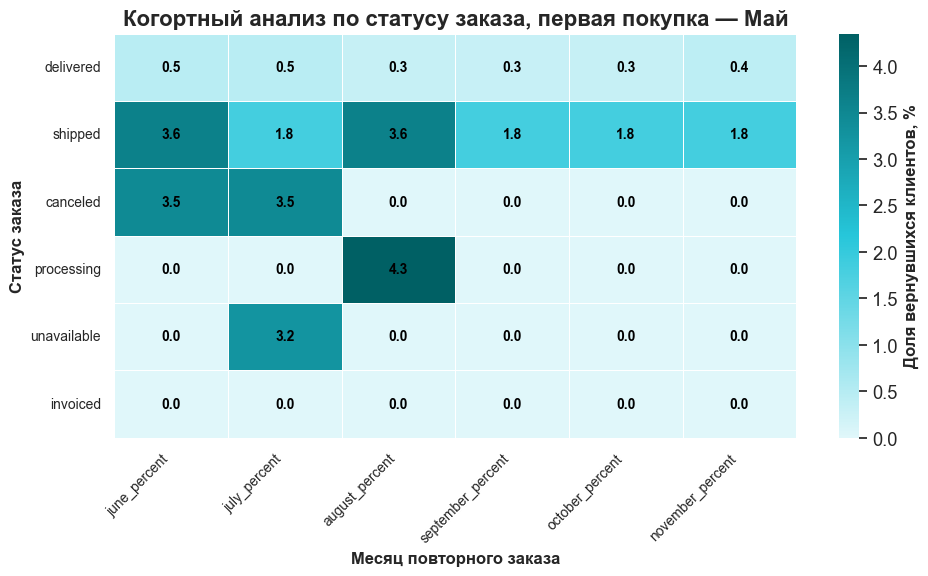

In [2]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    order_status,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_order_status_customers AS (
  SELECT
    fp.order_status,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  order_status, 
  total_customers,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_order_status_customers)
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('order_status', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

blue_palette = LinearSegmentedColormap.from_list("pretty_turquoise", ["#e0f7fa", "#26c6da", "#006064"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=blue_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по статусу заказа, первая покупка — Май", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Статус заказа", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по статусу заказа (%). Первая покупка - Апрель

C:\Users\Katem\AppData\Local\Temp\ipykernel_9340\3946833460.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,may_percent,june_percent,july_percent,august_percent,september_percent,october_percent,returnability_stability,rating
order_status,,,,,,,,,
delivered,2257,0.62,0.22,0.18,0.31,0.27,0.35,6,A
canceled,18,0.00,0.00,0.00,5.56,0.00,0.00,1,B
processing,10,0.00,0.00,0.00,0.00,0.00,0.00,0,C
shipped,48,0.00,0.00,0.00,0.00,0.00,0.00,0,C
unavailable,9,0.00,0.00,0.00,0.00,0.00,0.00,0,C
invoiced,14,0.00,0.00,0.00,0.00,0.00,0.00,0,C
approved,1,0.00,0.00,0.00,0.00,0.00,0.00,0,C


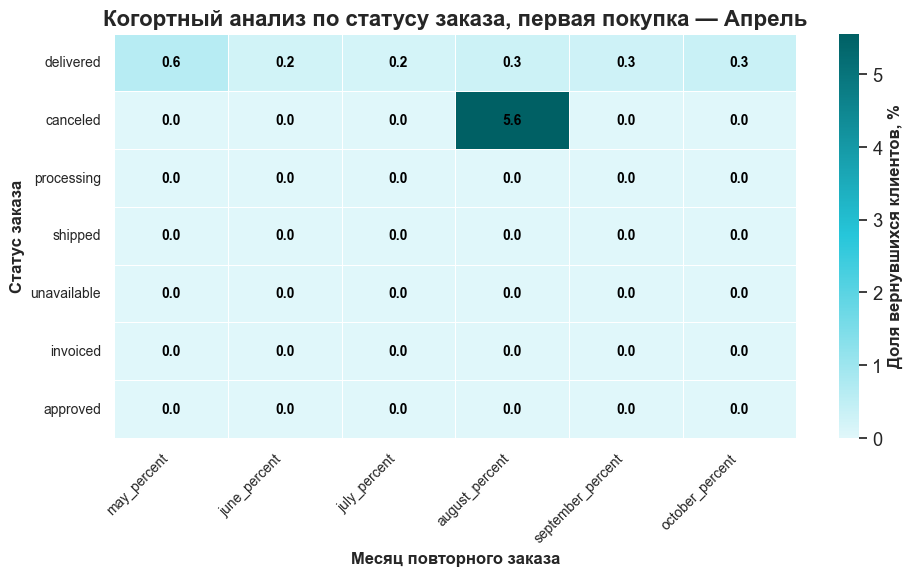

In [4]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    order_status,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_order_status_customers AS (
  SELECT
    fp.order_status,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'April' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October
  FROM
  orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'April'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  order_status, 
  total_customers,
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  (CASE WHEN May > 0 THEN 1 ELSE 0 END +
     CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_order_status_customers)
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('order_status', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['may_percent', 'june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

blue_palette = LinearSegmentedColormap.from_list("pretty_turquoise", ["#e0f7fa", "#26c6da", "#006064"], N=256)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=blue_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по статусу заказа, первая покупка — Апрель", fontsize=16, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Статус заказа", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Вывод: По когортному анализу в сравнении можно сделать вывод о стабильности возвращаемости клиентов.
По клиенту, чей первый заказ был успешно доставлен, всегда наблюдается стабильная возвращаемость во всех последующих месяцах. Это указывает на то, что первый позитивный опыт для покупателя очень важен, поскольку формирует его лояльность к сервису, тем самым повышая вероятность повторных заказов.
Для первой покупки со статусом заказа "canceled" также прослеживается удержание клиентов, но значительно не постоянное. В таком случае можно предположить, что часть покупателей могла отменить заказ самостоятельно по личным или техническим причинам, не связанным с недовольством сервиса, поэтому среди них может наблюдаться частичная возвращаемость.
По статусу заказа "shipped" прослеживается особенность в когорте с первой покупкой, сделанной в Мае. Здесь клиенты демонстрируют высокую и устойчивую возвращаемость на протяжении всего полугода, в отличие от других месяцев. Возможно, это связано с тем, что заказы в данном случае могли быть из штатов с высокой стабильностью удержания покупателей.
Для остальных статусов заказа возвращаемость клиентов имеет нулевой показатель, поскольку при первой покупке товар так и не был доставлен, что могло привести к полной потере доверия или интереса покупателя к сервису.  

### Подтверждение гипотезы по статусу заказа "shipped"

C:\Users\Katem\AppData\Local\Temp\ipykernel_23180\1804814865.py:100: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
C:\Users\Katem\AppData\Local\Temp\ipykernel_23180\1804814865.py:101: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_return = pd.read_sql_query(returnability_stability_query, conn)


,count_shipped_june,count_shipped_may,count_shipped_april
customer_state,,,
RJ,7,17,7
SP,16,11,14
MG,3,4,6
BA,0,3,7
SC,4,3,1
GO,5,3,3
PE,4,2,3
PI,0,2,0
PR,1,2,0


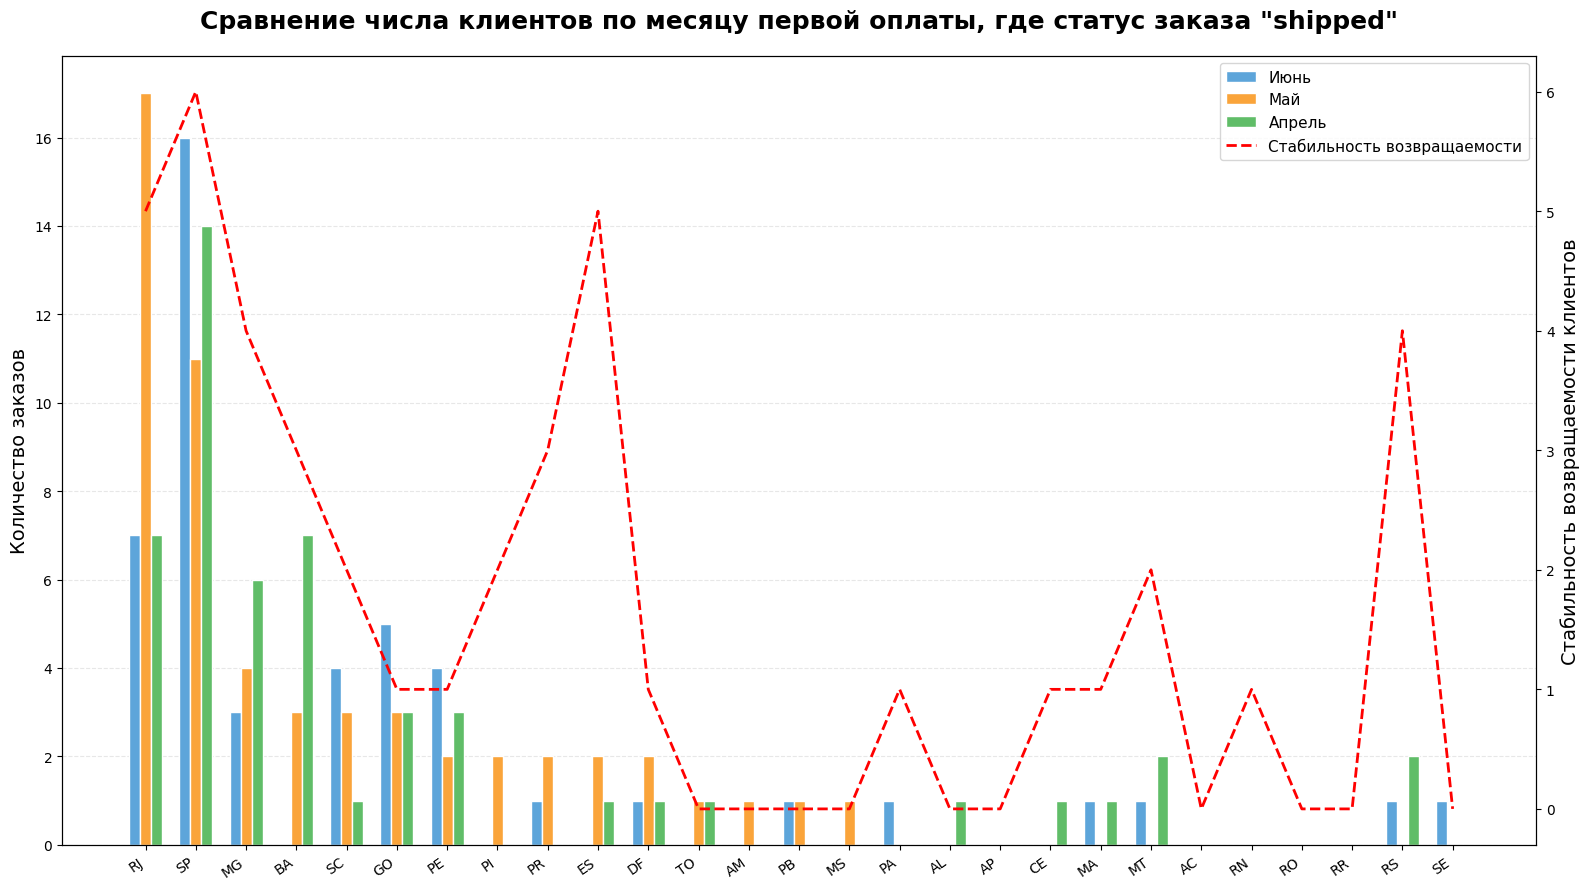

In [1]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    op.payment_type,
    o.order_status,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN order_payments op ON o.order_id = op.order_id
  JOIN customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2, 3, 4
)
SELECT
  customer_state,
  COUNT(CASE WHEN order_status = 'shipped' AND first_payment_month = 'June' THEN 1 END) AS count_shipped_june,
  COUNT(CASE WHEN order_status = 'shipped' AND first_payment_month = 'May' THEN 1 END) AS count_shipped_may,
  COUNT(CASE WHEN order_status = 'shipped' AND first_payment_month = 'April' THEN 1 END) AS count_shipped_april
FROM 
  first_payment
GROUP BY
  customer_state
ORDER BY
  count_shipped_may DESC;
'''

returnability_stability_query = '''
WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    c.customer_state,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1, 2
), cohort_state_customers AS (
  SELECT
    fp.customer_state,
    fp.first_payment_month,
  COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  JOIN 
    first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
)
SELECT 
  customer_state, 
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_state_customers
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)
df_return = pd.read_sql_query(returnability_stability_query, conn)

conn.close()

df.set_index('customer_state', inplace=True)
df_return.set_index('customer_state', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import matplotlib.pyplot as plt
import numpy as np

states_order = df.sort_values(by='count_shipped_may', ascending=False).index.tolist()
df_return = df_return.reindex(states_order)

colors = ['#5DA5DA', '#FAA43A', '#60BD68']
df_plot = df.loc[states_order]

x = np.arange(len(states_order)) * 1.6
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 9))

ax1.bar(x - bar_width, df_plot['count_shipped_june'], width=bar_width, color=colors[0], label='Июнь', edgecolor='white')
ax1.bar(x, df_plot['count_shipped_may'], width=bar_width, color=colors[1], label='Май', edgecolor='white')
ax1.bar(x + bar_width, df_plot['count_shipped_april'], width=bar_width, color=colors[2], label='Апрель', edgecolor='white')

# Вторая ось и линия стабильности
ax2 = ax1.twinx()
ax2.plot(x, df_return['returnability_stability'], color='red', linestyle='--', linewidth=2, label='Стабильность возвращаемости')
ax2.set_ylabel('Стабильность возвращаемости клиентов', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_xticks(x)
ax1.set_xticklabels(states_order, fontsize=10, rotation=35, ha='right')
ax1.set_ylabel('Количество заказов', fontsize=14)
ax1.set_title('Сравнение числа клиентов по месяцу первой оплаты, где статус заказа \"shipped\"', fontsize=18, fontweight='bold', pad=20)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

#### Когорты по категориям товара (%). Первая покупка - Июнь

C:\Users\Katem\AppData\Local\Temp\ipykernel_23180\512227510.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,july_percent,august_percent,september_percent,october_percent,november_percent,december_percent,returnability_stability,rating
product_category_name_english,,,,,,,,,
bed_bath_table,316,0.32,0.32,0.32,0.00,0.63,0.32,5,A
computers_accessories,215,0.47,0.93,0.00,0.47,0.93,0.93,5,A
health_beauty,231,0.87,0.43,0.43,0.00,0.43,0.43,5,A
sports_leisure,242,1.65,1.24,0.83,0.00,0.41,0.41,5,A
toys,155,0.65,0.00,0.00,0.65,0.65,0.65,4,A
furniture_decor,184,0.00,0.00,1.63,0.00,1.09,0.54,3,B
watches_gifts,118,0.00,0.00,0.00,1.69,0.00,0.85,2,B
auto,101,0.99,0.00,0.99,0.00,0.00,0.00,2,B
housewares,285,0.35,0.35,0.00,0.00,0.00,0.00,2,B


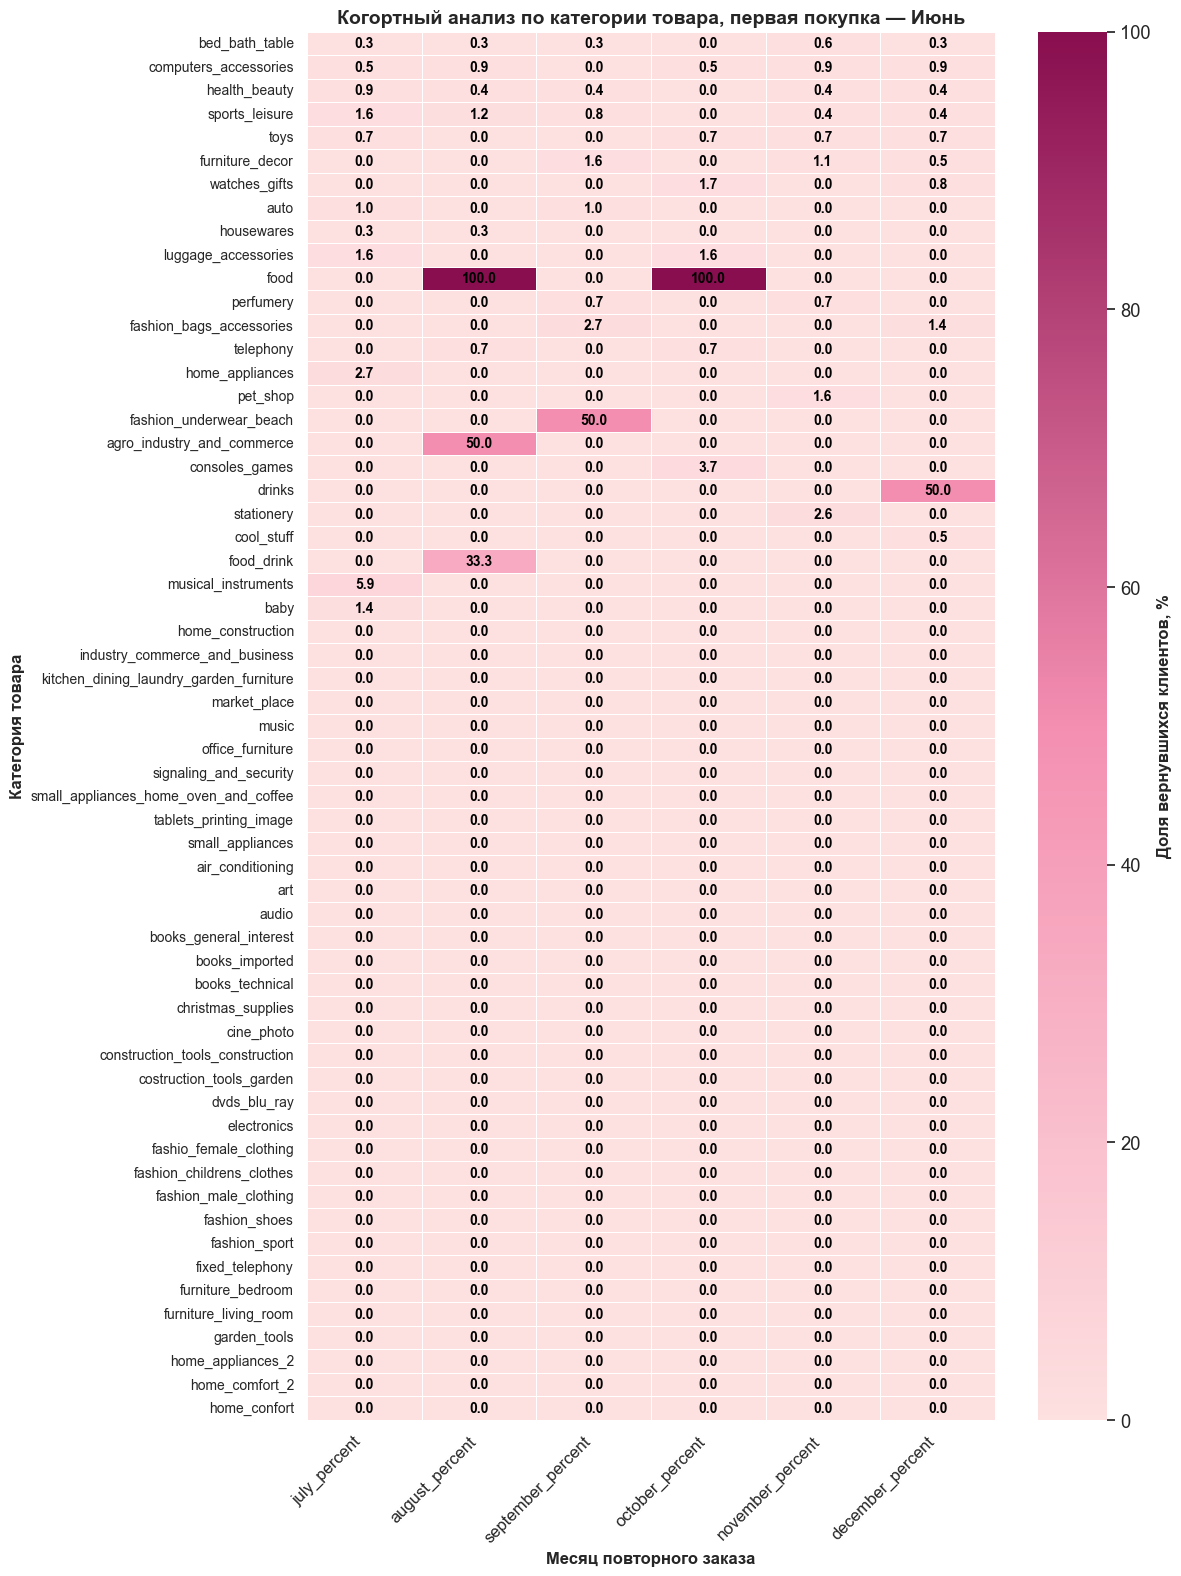

In [15]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1
), cohort_product_category_name_customers AS (
  SELECT
    pt.product_category_name_english,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'June' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'December' THEN fp.customer_unique_id END) AS December
  FROM
    orders o
  JOIN order_payments op ON o.order_id = op.order_id
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  JOIN orders_items oi ON o.order_id = oi.order_id
  JOIN products p ON oi.product_id = p.product_id
  JOIN product_category_name_translation pt ON p.product_category_name = pt.product_category_name
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'June'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  product_category_name_english, 
  total_customers,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  ROUND(December * 1.0 / total_customers * 100, 2) AS December_percent,
  (CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END +
     CASE WHEN December > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_product_category_name_customers)
  
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('product_category_name_english', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent', 'december_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

pink_palette = LinearSegmentedColormap.from_list("pink", ["#fde0e0", "#f48fb1", "#880e4f"], N=256)

plt.figure(figsize=(12, 16))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=pink_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по категории товара, первая покупка — Июнь", fontsize=14, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Категория товара", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по категориям товара (%). Первая покупка - Май 

C:\Users\Katem\AppData\Local\Temp\ipykernel_23180\4085742949.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,june_percent,july_percent,august_percent,september_percent,october_percent,november_percent,returnability_stability,rating
product_category_name_english,,,,,,,,,
sports_leisure,270,0.74,1.48,1.48,1.11,1.48,0.37,6,A
health_beauty,265,0.38,0.38,0.38,0.38,0.75,1.51,6,A
fashion_bags_accessories,90,2.22,2.22,1.11,0.00,1.11,2.22,5,A
housewares,263,0.76,0.38,0.00,0.76,0.38,0.38,5,A
telephony,205,0.98,0.49,0.00,0.00,0.49,0.49,4,A
toys,197,0.51,0.00,0.51,0.51,0.00,0.51,4,A
cool_stuff,241,0.41,0.41,0.00,0.41,0.83,0.00,4,A
garden_tools,127,0.00,0.79,0.00,0.79,0.00,0.79,3,B
consoles_games,29,3.45,3.45,0.00,0.00,3.45,0.00,3,B


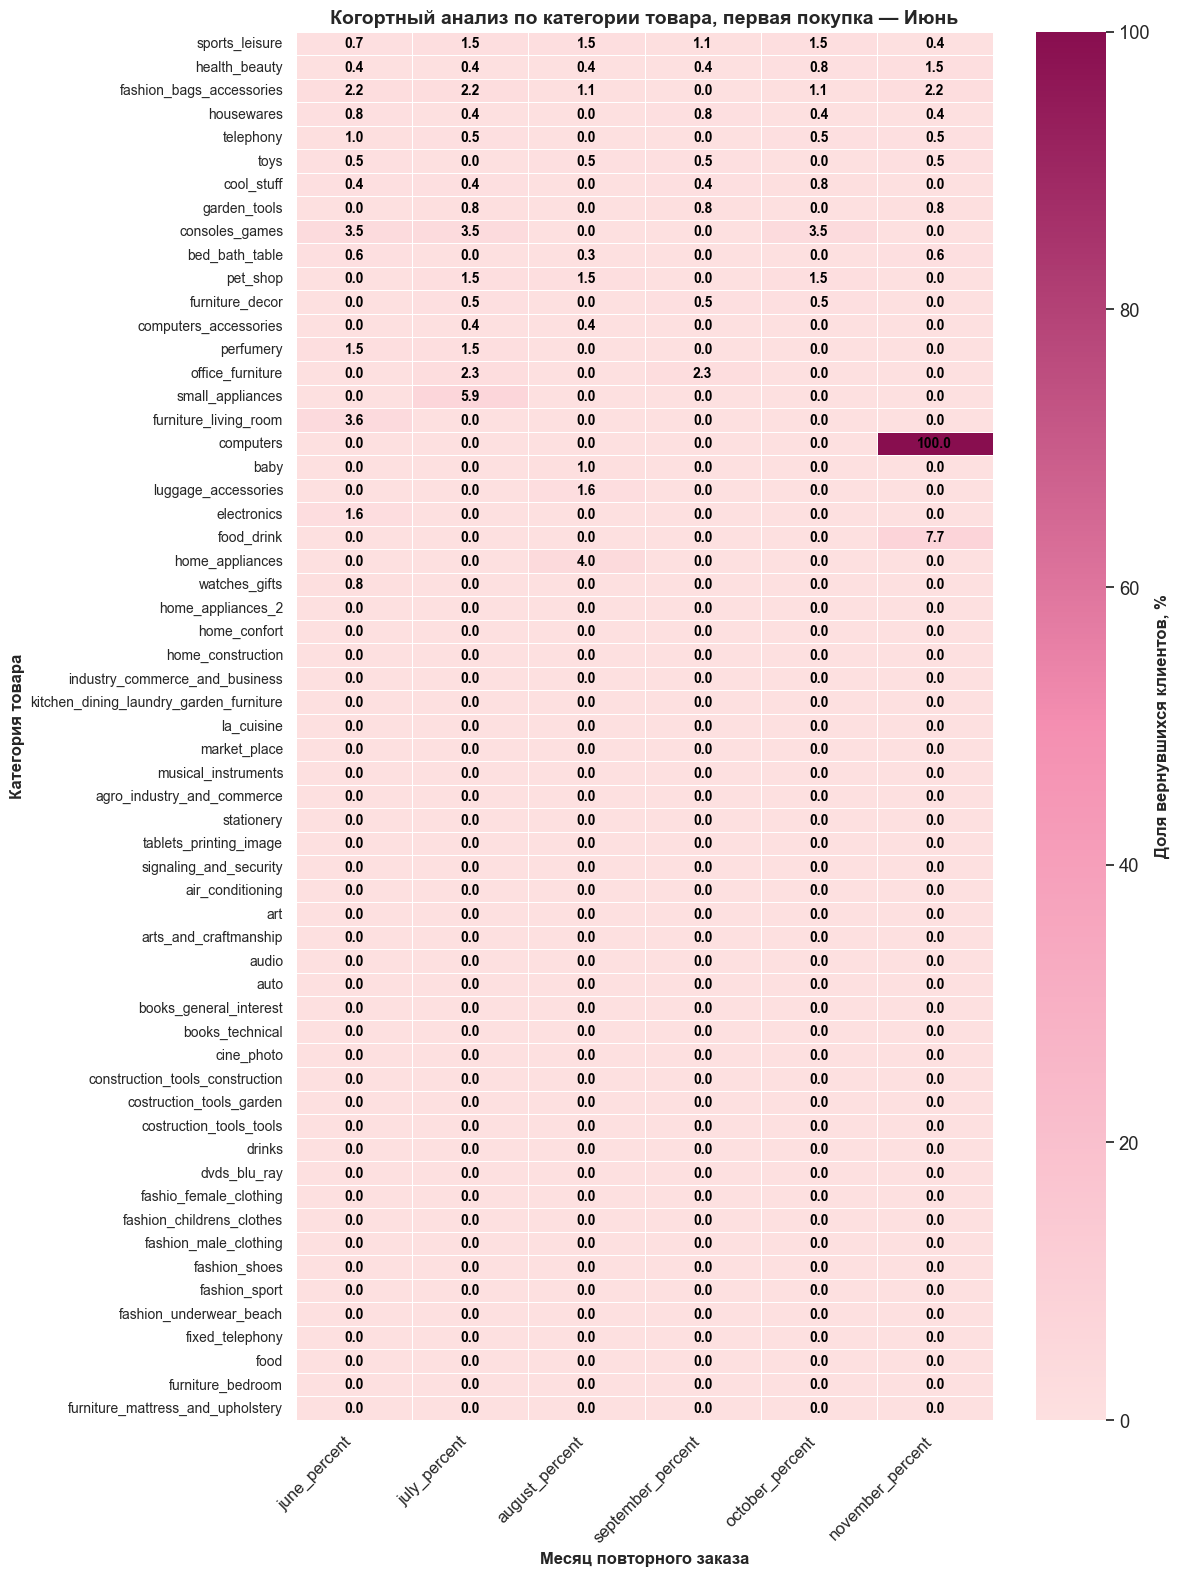

In [16]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1
), cohort_product_category_name_customers AS (
  SELECT
    pt.product_category_name_english,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'May' THEN fp.customer_unique_id END) AS total_customers,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'November' THEN fp.customer_unique_id END) AS November
  FROM
    orders o
  JOIN order_payments op ON o.order_id = op.order_id
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  JOIN orders_items oi ON o.order_id = oi.order_id
  JOIN products p ON oi.product_id = p.product_id
  JOIN product_category_name_translation pt ON p.product_category_name = pt.product_category_name
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'May'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  product_category_name_english, 
  total_customers,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent, 
  ROUND(November * 1.0 / total_customers * 100, 2) AS November_percent,
  (CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END +
     CASE WHEN November > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_product_category_name_customers)
  
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('product_category_name_english', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent', 'november_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

pink_palette = LinearSegmentedColormap.from_list("pink", ["#fde0e0", "#f48fb1", "#880e4f"], N=256)

plt.figure(figsize=(12, 16))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=pink_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по категории товара, первая покупка — Июнь", fontsize=14, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Категория товара", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### Когорты по категориям товара (%). Первая покупка - Апрель

C:\Users\Katem\AppData\Local\Temp\ipykernel_23180\2695452282.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,total_customers,may_percent,june_percent,july_percent,august_percent,september_percent,october_percent,returnability_stability,rating
product_category_name_english,,,,,,,,,
sports_leisure,198,0.51,1.01,1.01,1.01,0.00,0.51,5,A
furniture_decor,168,2.38,0.00,0.00,0.60,0.60,0.60,4,A
computers_accessories,121,0.83,0.00,0.00,0.00,0.83,0.83,3,B
health_beauty,175,1.14,0.00,0.57,0.00,0.00,1.14,3,B
bed_bath_table,225,0.44,0.00,0.00,0.89,0.00,0.89,3,B
fashion_bags_accessories,47,2.13,0.00,2.13,0.00,0.00,2.13,3,B
perfumery,102,0.00,0.98,0.98,0.00,0.00,0.00,2,B
auto,82,0.00,1.22,0.00,1.22,0.00,0.00,2,B
pet_shop,47,2.13,0.00,0.00,4.26,0.00,0.00,2,B


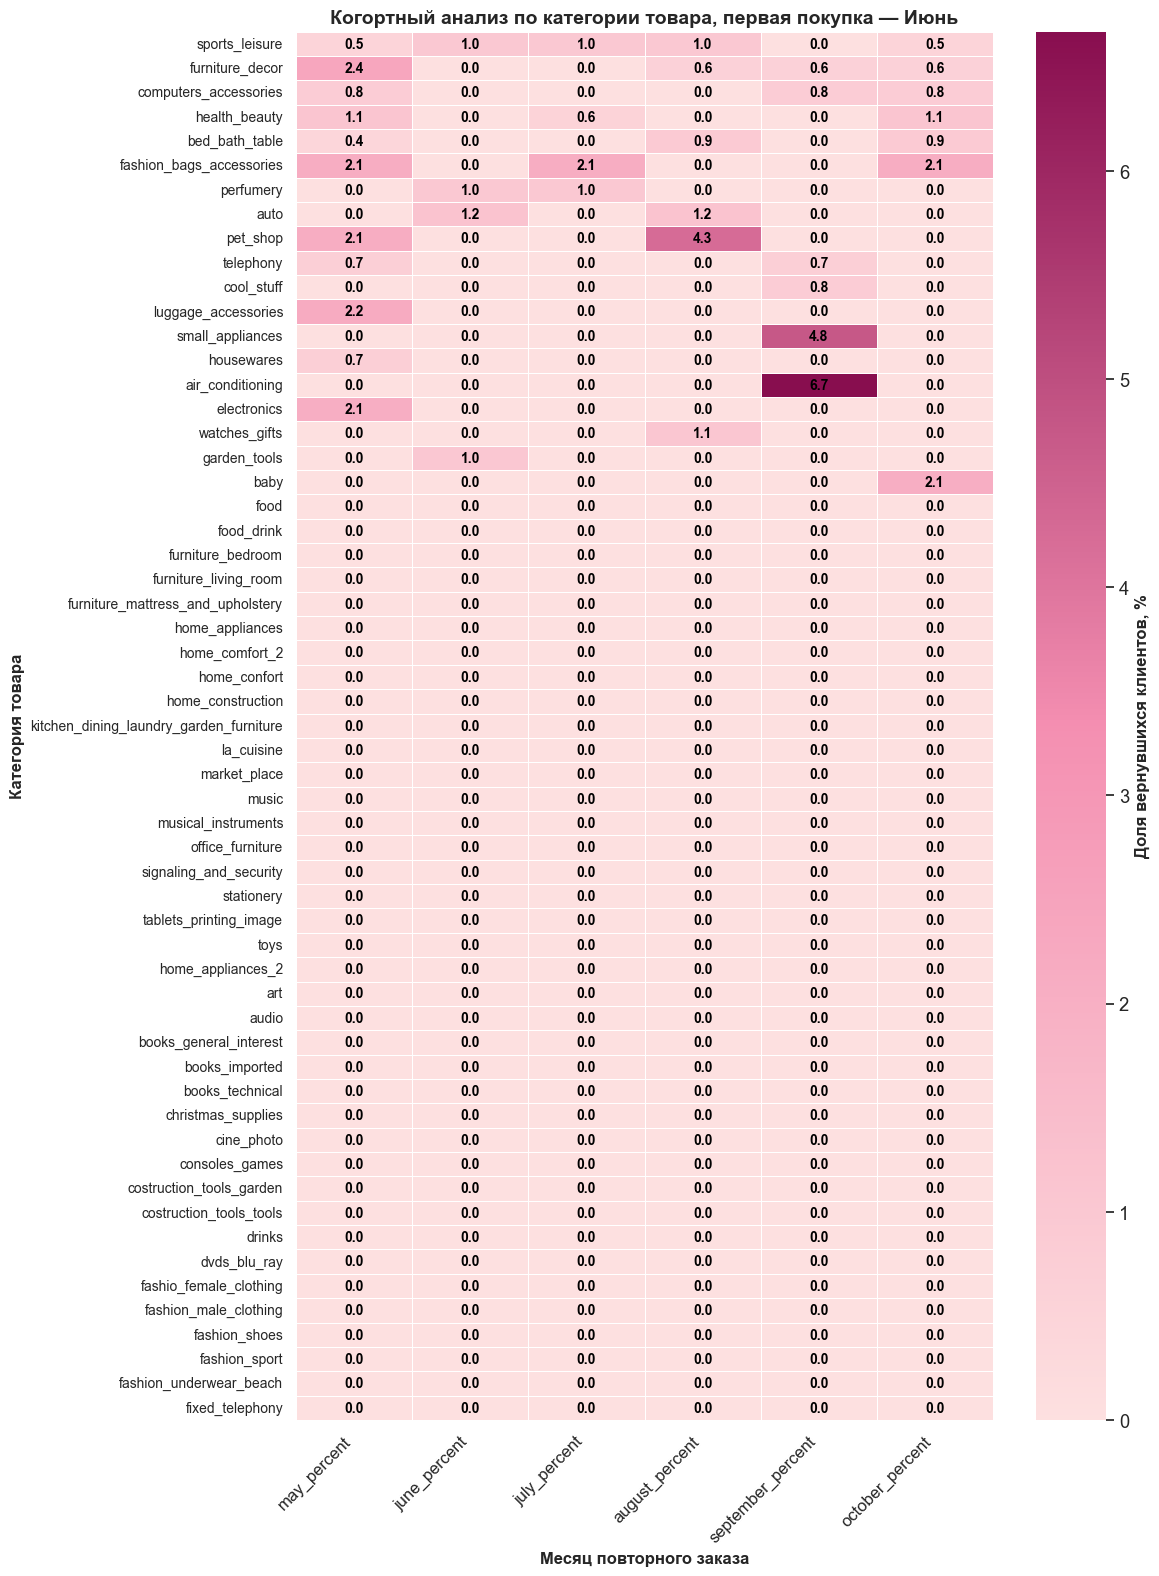

In [17]:
import pandas as pd
import psycopg2
from IPython.display import display

conn = psycopg2.connect(
    dbname='Rostelecom',
    user='postgres',
    password='2714',
    host='localhost',
    port='5432'
)

query = '''
  WITH first_payment AS (
  SELECT
    c.customer_unique_id,
    TO_CHAR(MIN(o.order_purchase_timestamp), 'FMMonth') AS first_payment_month
  FROM 
    orders o 
  JOIN 
    order_payments op ON o.order_id = op.order_id
  JOIN 
    customers c ON o.customer_id = c.customer_id
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01'
  GROUP BY
    1
), cohort_product_category_name_customers AS (
  SELECT
    pt.product_category_name_english,
    fp.first_payment_month,
    COUNT(DISTINCT CASE WHEN first_payment_month = 'April' THEN fp.customer_unique_id END) AS total_customers,
	COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'May' THEN fp.customer_unique_id END) AS May,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'June' THEN fp.customer_unique_id END) AS June,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'July' THEN fp.customer_unique_id END) AS July,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'August' THEN fp.customer_unique_id END) AS August,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'September' THEN fp.customer_unique_id END) AS September,
    COUNT(DISTINCT CASE WHEN TO_CHAR(o.order_purchase_timestamp, 'FMMonth') = 'October' THEN fp.customer_unique_id END) AS October
  FROM
    orders o
  JOIN order_payments op ON o.order_id = op.order_id
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN first_payment fp ON c.customer_unique_id = fp.customer_unique_id
  JOIN orders_items oi ON o.order_id = oi.order_id
  JOIN products p ON oi.product_id = p.product_id
  JOIN product_category_name_translation pt ON p.product_category_name = pt.product_category_name
  WHERE 
    date(o.order_purchase_timestamp) >= '2017-01-01' AND 
    date(o.order_purchase_timestamp) < '2018-01-01' AND
    fp.first_payment_month = 'April'
  GROUP BY 
    1, 2
), cohort_with_returnability_stability AS(
SELECT 
  product_category_name_english, 
  total_customers,
  ROUND(May * 1.0 / total_customers * 100, 2) AS May_percent,
  ROUND(June * 1.0 / total_customers * 100, 2) AS June_percent,
  ROUND(July * 1.0 / total_customers * 100, 2) AS July_percent, 
  ROUND(August * 1.0 / total_customers * 100, 2) AS August_percent, 
  ROUND(September * 1.0 / total_customers * 100, 2) AS September_percent,
  ROUND(October * 1.0 / total_customers * 100, 2) AS October_percent,
  (CASE WHEN May > 0 THEN 1 ELSE 0 END +
  	 CASE WHEN June > 0 THEN 1 ELSE 0 END +
     CASE WHEN July > 0 THEN 1 ELSE 0 END +
     CASE WHEN August > 0 THEN 1 ELSE 0 END +
     CASE WHEN September > 0 THEN 1 ELSE 0 END +
     CASE WHEN October > 0 THEN 1 ELSE 0 END) AS returnability_stability
FROM
  cohort_product_category_name_customers)
  
SELECT 
*,
(CASE 
	WHEN returnability_stability > 3 THEN 'A'
	WHEN returnability_stability > 0 AND returnability_stability <= 3 THEN 'B'
	WHEN returnability_stability = 0 THEN 'C'
 END) AS rating
FROM 
cohort_with_returnability_stability
ORDER BY returnability_stability DESC;
'''

df = pd.read_sql_query(query, conn)

conn.close()

df.set_index('product_category_name_english', inplace=True)

if df.empty:
    print("Запрос не вернул никаких данных.")
else:
    display(df)

# ВИЗУАЛИЗАЦИЯ

import seaborn as sns
import matplotlib.pyplot as plt

percent_columns = ['may_percent', 'june_percent', 'july_percent', 'august_percent', 'september_percent', 'october_percent']
heatmap_df = df[percent_columns].copy()

sns.set(style="white", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "medium"})

from matplotlib.colors import LinearSegmentedColormap

pink_palette = LinearSegmentedColormap.from_list("pink", ["#fde0e0", "#f48fb1", "#880e4f"], N=256)

plt.figure(figsize=(12, 16))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap=pink_palette,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Доля вернувшихся клиентов, %'},
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": "black"}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Доля вернувшихся клиентов, %', fontsize=12)

plt.title("Когортный анализ по категории товара, первая покупка — Июнь", fontsize=14, fontweight='bold')
plt.xlabel("Месяц повторного заказа", fontsize=12, fontweight='bold')
plt.ylabel("Категория товара", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Вывод: Сравнив между собой три когорты клиентов, которые первый заказ сделали в Июне, Мае и Апреле соответственно, совершивших первый заказ в Июне, Мае и Апреле, соответсвенно, можно выделить ряд закономерностей в поведении потребителей по разным категориям товаров. 
Категории, которые домонстрируют высокую стабильность возвращаемости - sports_leisure, health_beauty, bed_bath_table. Они выделяются постоянной вовлеченностью клиентов, вне зависимости от месяца первой покупки. Вероятнее всего, это связано с тем, что товары в данных категориях удовлетворяют ежедневные потребности или касаются качества жизни и комфорта, из-за чего имеют регулярный спрос. Также стоит отметить, что такие категории могут обладать высокой частотой повторных заказов благодаря низкому сроку службы и расходуемости товаров, устойчивой привычке потребления и позитивному пользовательскому опыту, например, вследствие удовлетворения качеством.
Среди категорий с достаточно низкой или нулевой стабильностью возвращаемости выделяются small_appliances, electronics, garden_tools и baby. Несмотря на то, что общее количество клиентов в этих категориях может быть средним или даже высоким, их повторная активность крайне ограничена. Из возможных причин этому могут быть: 
- ожидания, которые не соотвествуют реальному качеству товаров (особенно критично для категории baby, где клиенты особенно чувствительны к качеству и безопасности); 
- длительный срок службы товаров (покупки электроники или мелкой бытовой техники совершаются редко и естественная потребность в повторных заказах в большистве случаев возникает нескоро)
- сезонность (среди выделенных категорий это относится к садовым инструментам. Причем в когорте, где первая покупка клиентов была сделана в Мае, прослеживается более высокая стабильность возвращаемости по garden_tools относительно остальных когорт, что подтверждает фактор сезонности)
Остальные категории, в которых очень низкий показатель retention, обладают небольшим количеством клиентов в целом, поэтому вероятность повторного совершения заказа небольшая.